In [6]:
import cme.decision_models.diffusion_discrete as dd
import cme.decision_models.quantum_discrete as qd
import jax.numpy as npx
import jax.scipy as sci
import pandas as pd
import seaborn as sns
import numpy as np

In [7]:
n_states, start_width, mu, sigma, delta = 7,1, npx.asarray([[2]]), npx.asarray([[1]]), 1

In [8]:
q_H = qd._buildH(n_states, mu, sigma).squeeze()
q_H

Array([[-6.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 1., -4.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  2.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  4.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  6.]], dtype=float64)

In [9]:
q_init = qd._get_initial_state(n_states, start_width).squeeze()
q_init

Array([0.        , 0.        , 0.57735027, 0.57735027, 0.57735027,
       0.        , 0.        ], dtype=float64)

In [10]:
q_Mc, q_Mw, q_Mnor = qd._get_measurement_matrix(n_states, start_width,prob=0.25)
q_Mc**2 + q_Mw**2 + q_Mnor**2

Array([[1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float64)

# Likelihood Function


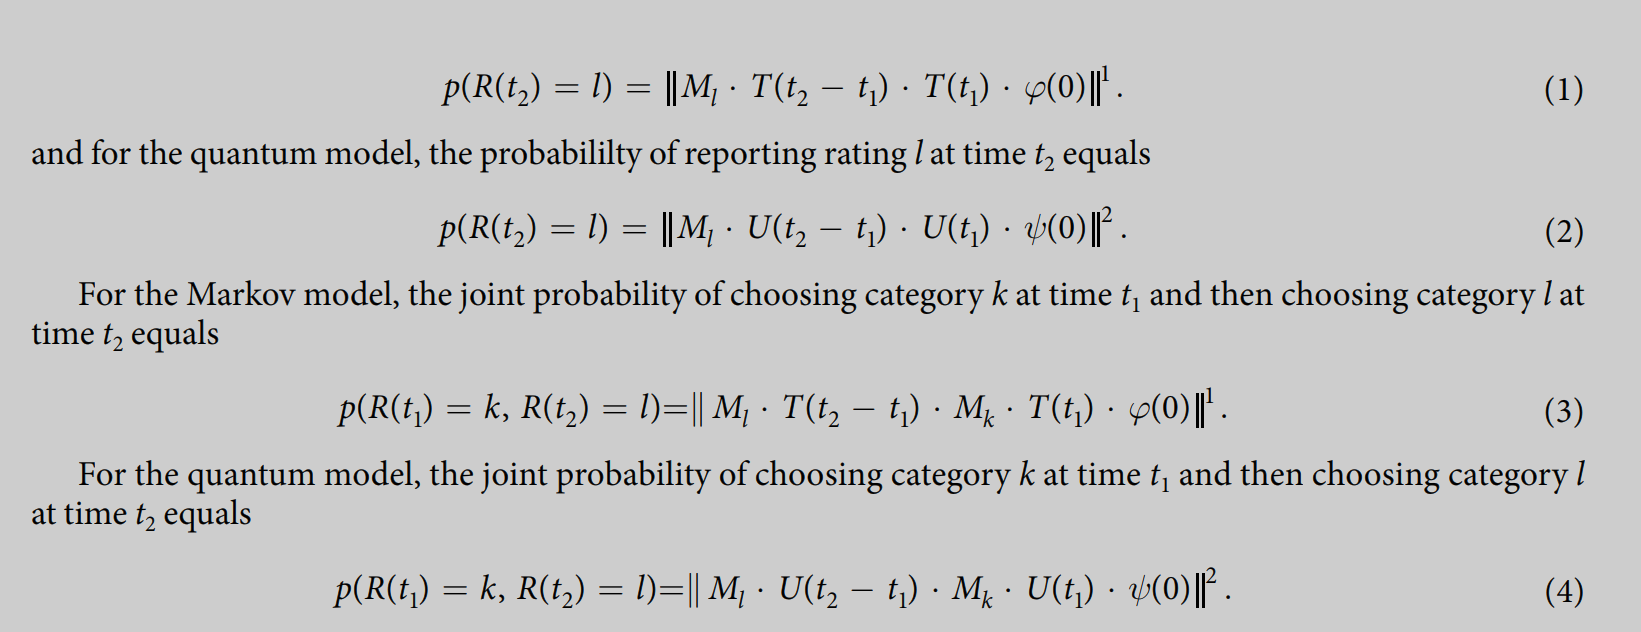

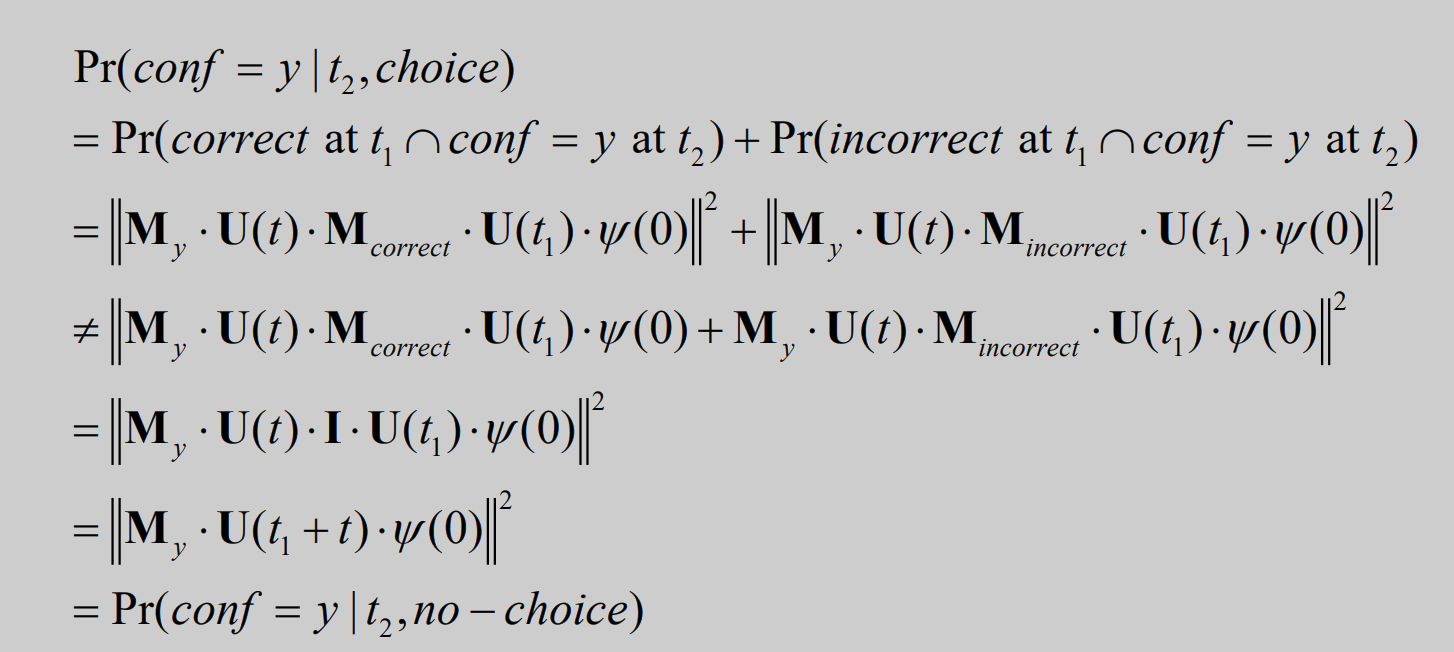

In [11]:
t1 = 10
t2 = 12




## State Transition

In [15]:
phi_0 = q_init
t = t1
H = q_H

phi_t = sci.linalg.expm(-1j * q_H * t) @ phi_0
phi_t

Array([ 0.09121108+0.03723983j,  0.24927153+0.01203128j,
        0.21516698+0.13347508j,  0.411066  -0.43689942j,
       -0.09705916-0.5703745j , -0.32884345+0.18198053j,
        0.1436099 -0.08612562j], dtype=complex128)

## Likelihood

In [18]:
Mc = q_Mc

likl_c = npx.abs(Mc @ phi_t)**2
likl_c

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00701036], dtype=float64)

In [19]:
Mw = q_Mw
likl_w = npx.abs(Mw @ phi_t)**2
likl_w

Array([0.00242657, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ], dtype=float64)

## Mean Confidence

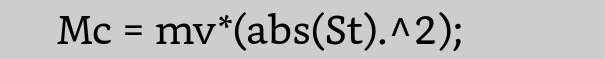

In [20]:
Mid = (n_states + 1)//2
mv = npx.arange(-(Mid-1), (Mid))[None,:]
mv

Array([[-3, -2, -1,  0,  1,  2,  3]], dtype=int64)

In [22]:
mean_conf = mv @ npx.abs(phi_t)**2
mean_conf

Array([0.48358836], dtype=float64)